# Two-level atom in the presence of an external field

Consider a non-degenerate two-level atom $(\ket{0},\ket{1})$ subjected to a classical, monochromatic (frequency $\omega_f$) and linearly polarized electric field. Without loss of generality, we choose the $x$ axis as the polarization direction and write the field as
$$\vec{\mathcal{E}} = (\mathcal{E}_0 \cos(\omega_f t)0,0) 
$$ 

The Hamiltonian takes the form 
$$ \hat H = \frac{\hbar\omega_a}{2} \hat\sigma_z + 2\hbar(g\hat\sigma_+ + g^* \hat\sigma_-)\cos(\omega_f t) \quad \text{(Rabi semiclassical Hamiltonian)}
$$
where
* $\omega_a = (E_1-E_0)/\hbar$ is the transition frequency of the atom.
* $g = - \frac{e\mathcal{E}_0}{2\hbar} \bra{1}\hat x\ket{0}$ is the coupling constant between the atom and the field. In practice, it defines the time scale of the system's evolution.

*Note:* Without loss of generality, we will consider a real $g$.

## Solution in the rotated frame

To simplify the Schrödinger equation, it is convenient to work in a rotated frame
$$\ket{\psi(t)}_R = e^{i\frac{\omega_f t}{2}\hat \sigma_z} \ket{\psi(t)} = c_0(t)\ket{0} + c_1(t)\ket{1} 
$$
resulting in 
$$ i\frac{d c_1}{dt} = \frac{\Delta}{2}c_1 + g(1+e^{2i\omega_{f} t})c_0 \\[4pt]
i\frac{d c_0}{dt} = -\frac{\Delta}{2}c_0 + g^*(1+e^{-2i\omega_{f} t})c_1 
$$
where 
* $\Delta = \omega_a - \omega_f$ is the detuning parameter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d.art3d import Line3DCollection



In [2]:
# Model parameters
omega_f = 21  # Laser frequency
omega_a = 20  # Atomic frequency
g = 1         # Coupling parameter
Delta = omega_f - omega_a  # Detuning

# System of differential equations
def rabi_semiclassical(t, C):
    c0, c1 = C
    dc0dt = -1j * Delta/2 * c0 - 1j * g * (1 + np.exp(-2j * omega_f * t)) * c1
    dc1dt =  1j * Delta/2 * c1 - 1j * g * (1 + np.exp(2j * omega_f * t)) * c0
    return [dc0dt, dc1dt]

# Initial conditions
C0 = [1.0 + 0.0j, 0.0 + 0.0j]

# Time interval
t_span = (0.0, 3.0)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# Solve the system
sol = solve_ivp(rabi_semiclassical, t_span, C0, t_eval=t_eval, method='RK45')

# Extract results
t = sol.t
c0 = sol.y[0]
c1 = sol.y[1]

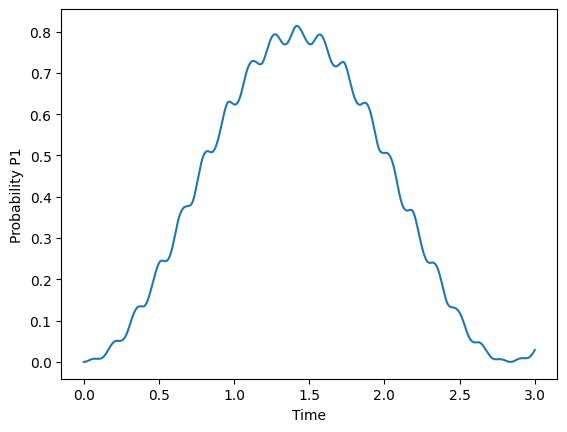

In [3]:
# Probabilities
p0 = np.abs(c0)**2
p1 = np.abs(c1)**2

# Plot of p1 (Probability of finding the system in the excited state)
plt.plot(t, p1)
plt.xlabel('Time')
plt.ylabel('Probability P1')
plt.show()

In [4]:
def bloch_xyz(c1, c0):
    x = 2 * np.real(c1 * np.conj(c0))
    y = 2 * np.imag(c1 * np.conj(c0))
    z = np.abs(c1)**2 - np.abs(c0)**2
    return x, y, z

def bloch_sphere(ax, alpha=0.15):
    # Draw sphere
    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 50)
    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_surface(
        x, y, z,
        color='lightblue', alpha=alpha,
        edgecolor='gray', linewidth=0.1, shade=True
    )

    # Draw guide circles
    theta = np.linspace(0, 2 * np.pi, 100)
    # Equator
    ax.plot(np.cos(theta), np.sin(theta), 0 * theta, 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    # XZ meridian
    ax.plot(np.cos(theta), 0 * theta, np.sin(theta), 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    # YZ meridian
    ax.plot(0 * theta, np.cos(theta), np.sin(theta), 'gray',
            alpha=0.3, linewidth=0.8, linestyle='--')
    
    # Coordinate axes
    axis_length = 1.3
    ax.plot([-axis_length, axis_length], [0, 0], [0, 0],
            'k-', linewidth=1.5, alpha=0.6)
    ax.plot([0, 0], [-axis_length, axis_length], [0, 0],
            'k-', linewidth=1.5, alpha=0.6)
    ax.plot([0, 0], [0, 0], [-axis_length, axis_length],
            'k-', linewidth=1.5, alpha=0.6)

    # Axis labels
    offset = 1.5
    ax.text(offset, 0, 0, r'$\langle\hat{\sigma}_x\rangle$',
            fontsize=14, ha='center')
    ax.text(0, offset, 0, r'$\langle\hat{\sigma}_y\rangle$',
            fontsize=14, ha='center')
    ax.text(0, 0, offset, r'$\langle\hat{\sigma}_z\rangle$',
            fontsize=14, ha='center')
    
    # Basis states
    ax.text(0, 0, 1.3, r'$|1\rangle$', fontsize=16, color='darkblue',
            fontweight='bold', ha='center')
    ax.text(0, 0, -1.3, r'$|0\rangle$', fontsize=16, color='darkred',
            fontweight='bold', ha='center')
    
    # View configuration
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
    ax.set_zlim([-1.2, 1.2])
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()
    ax.view_init(elev=20, azim=45)

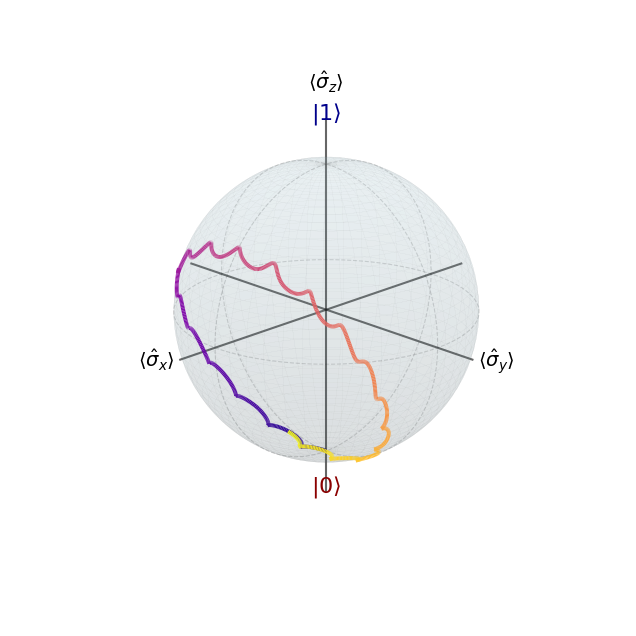

In [5]:
# Plot in the rotating frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
bloch_sphere(ax, alpha=0.10)

# Trajectory on the Bloch sphere
x, y, z = bloch_xyz(c1, c0)

points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=t.min(), vmax=t.max())
cmap = plt.get_cmap("plasma")

lc = Line3DCollection(segments, cmap=cmap, norm=norm)
lc.set_array(t[:-1])
lc.set_linewidth(2.8)
lc.set_alpha(0.95)
ax.add_collection3d(lc)


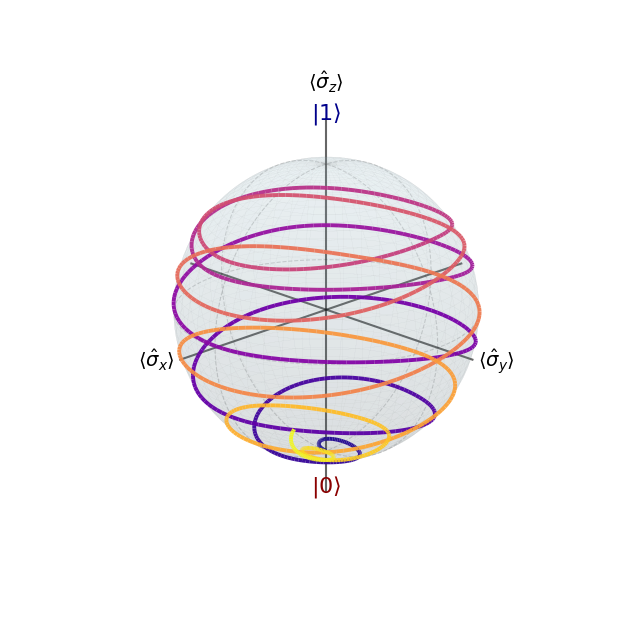

In [6]:
# Plot in the laboratory frame
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
bloch_sphere(ax, alpha=0.10)

# Trajectory on the Bloch sphere
x, y, z = bloch_xyz(c1 * np.exp(-1j * omega_f/2 * t), c0 * np.exp(1j * omega_f/2 * t))

points = np.array([x, y, z]).T.reshape(-1, 1, 3)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

norm = Normalize(vmin=t.min(), vmax=t.max())
cmap = plt.get_cmap("plasma")

lc = Line3DCollection(segments, cmap=cmap, norm=norm)
lc.set_array(t[:-1])
lc.set_linewidth(2.8)
lc.set_alpha(0.95)
ax.add_collection3d(lc)

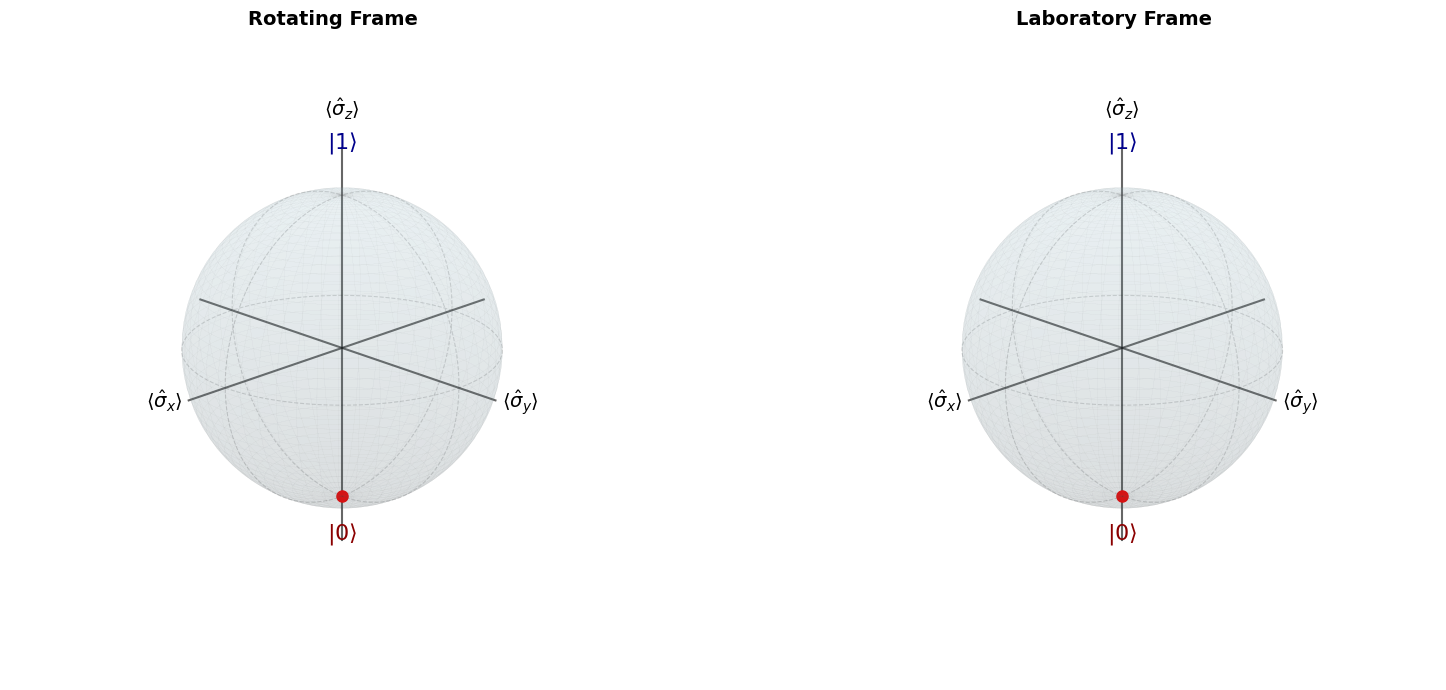

In [7]:
from matplotlib.animation import FuncAnimation

# Create figure with two subplots (rotating frame and laboratory)
fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Configure Bloch spheres
bloch_sphere(ax1, alpha=0.10)
bloch_sphere(ax2, alpha=0.10)

ax1.set_title('Rotating Frame', fontsize=14, fontweight='bold')
ax2.set_title('Laboratory Frame', fontsize=14, fontweight='bold')

# Trajectory vectors in rotating frame
x_rot, y_rot, z_rot = bloch_xyz(c1, c0)

# Trajectory vectors in laboratory frame
x_lab, y_lab, z_lab = bloch_xyz(c1 * np.exp(-1j * omega_f/2 * t), c0 * np.exp(1j * omega_f/2 * t))

# Lines for the trajectories
line1, = ax1.plot([], [], [], 'b-', linewidth=2, alpha=0.7)
point1, = ax1.plot([], [], [], 'ro', markersize=8)

line2, = ax2.plot([], [], [], 'b-', linewidth=2, alpha=0.7)
point2, = ax2.plot([], [], [], 'ro', markersize=8)

# Number of points to show in the trajectory
trail_length = 50

def animate(frame):
    # Rotating frame
    start_idx = max(0, frame - trail_length)
    line1.set_data(x_rot[start_idx:frame], y_rot[start_idx:frame])
    line1.set_3d_properties(z_rot[start_idx:frame])
    point1.set_data([x_rot[frame]], [y_rot[frame]])
    point1.set_3d_properties([z_rot[frame]])
    
    # Laboratory frame
    line2.set_data(x_lab[start_idx:frame], y_lab[start_idx:frame])
    line2.set_3d_properties(z_lab[start_idx:frame])
    point2.set_data([x_lab[frame]], [y_lab[frame]])
    point2.set_3d_properties([z_lab[frame]])
    
    return line1, point1, line2, point2

# Create animation
anim = FuncAnimation(fig, animate, frames=len(t), interval=20, blit=True, repeat=True)
plt.tight_layout()
plt.show()

# Guardar la animación como GIF
anim.save('bloch_sphere_animation.gif', writer='pillow', fps=30)